# Second model (goal=0.127992 (top 1000))

In [812]:
# Librerías para manipulación de datos y visualización
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Configuración para que se muestren bien los gráficos
%matplotlib inline
print("Librerías importadas correctamente.")




Librerías importadas correctamente.


In [813]:
 # Cargar los datos
df = pd.read_csv('../data/train.csv', index_col='Id')

# Mostrar las primeras 5 filas para confirmar la carga
print("Primeras 5 filas del dataset:")
df.head()

Primeras 5 filas del dataset:


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [814]:
#hago un dataframe numerico
dfNum=df.select_dtypes(include=['float64', 'int64'])
#extraigo las columnas que no son numéricas
dfCat = df.select_dtypes(exclude=['float64', 'int64'])
Categorias=dfCat.columns.tolist()

# UnprecisecorrMatrix
corr_matrix = dfNum.corr()

dfNumClean=dfNum.copy()

columns_to_clean=['GarageArea', 'TotalBsmtSF', 'MasVnrArea', 'BsmtFinSF1', 'WoodDeckSF','2ndFlrSF', 'OpenPorchSF', 'BsmtUnfSF', 'EnclosedPorch','ScreenPorch','PoolArea','3SsnPorch','LowQualFinSF','MiscVal','BsmtFinSF2']
#new corr
corr_matrix_2= dfNumClean.corr()['SalePrice'].drop('SalePrice')
new_corr= {}
#calc corr with saleprice for each feature independently
for column in columns_to_clean:
    new_corr[column]=dfNumClean[dfNumClean[column]!=0].corr()['SalePrice'][column]

dic_ordenado = dict(sorted(new_corr.items(), key=lambda x: x[1], reverse=True))

#substituing old with new correlations
for i in corr_matrix_2.index:
    if i in columns_to_clean:
        corr_matrix_2[i] = dic_ordenado[i]

#ordering
corr_matrix_2=corr_matrix_2.sort_values(ascending=False)
print(corr_matrix_2)



OverallQual      0.790982
GrLivArea        0.708624
2ndFlrSF         0.673305
GarageCars       0.640409
TotalBsmtSF      0.609681
GarageArea       0.608405
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
BsmtFinSF1       0.471690
Fireplaces       0.466929
MasVnrArea       0.434090
LotFrontage      0.351799
LowQualFinSF     0.300075
HalfBath         0.284108
LotArea          0.263843
ScreenPorch      0.255430
EnclosedPorch    0.241279
BsmtFullBath     0.227122
BsmtFinSF2       0.198956
WoodDeckSF       0.193706
BsmtUnfSF        0.169261
BedroomAbvGr     0.168213
MiscVal          0.088963
OpenPorchSF      0.086453
3SsnPorch        0.063932
MoSold           0.046432
PoolArea        -0.014092
BsmtHalfBath    -0.016844
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
KitchenAbvGr    -0.135907
Name: SalePrice, dtype: float64


In [815]:
df_pred=df.copy()

In [816]:
forlinearfeatures=corr_matrix_2
n=25 #No, of variables to use

In [817]:

for col in forlinearfeatures.index[:n].tolist():
    df_pred[col]=df_pred[col].fillna(df_pred[col].median())

y=df_pred['SalePrice']
df_pred[forlinearfeatures.index[:n].tolist() + ['SalePrice']].head()



,OverallQual,GrLivArea,2ndFlrSF,GarageCars,TotalBsmtSF,GarageArea,1stFlrSF,FullBath,TotRmsAbvGrd,YearBuilt,...,LowQualFinSF,HalfBath,LotArea,ScreenPorch,EnclosedPorch,BsmtFullBath,BsmtFinSF2,WoodDeckSF,BsmtUnfSF,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,7,1710,854,2,856,548,856,2,8,2003,...,0,1,8450,0,0,1,0,0,150,208500
2,6,1262,0,2,1262,460,1262,2,6,1976,...,0,0,9600,0,0,0,0,298,284,181500
3,7,1786,866,2,920,608,920,2,6,2001,...,0,1,11250,0,0,1,0,0,434,223500
4,7,1717,756,3,756,642,961,1,7,1915,...,0,0,9550,0,272,1,0,0,540,140000
5,8,2198,1053,3,1145,836,1145,2,9,2000,...,0,1,14260,0,0,1,0,192,490,250000


In [818]:
df_pred_no_SP= df_pred[forlinearfeatures.index[:n].tolist()].copy()

In [819]:
for column in columns_to_clean:
    if column in df_pred_no_SP.columns:
        df_pred_no_SP[f'has {column}']=(df_pred_no_SP[column]>0).astype(int)
        df_pred_no_SP

df_pred_no_SP
final_df_for_reg=df_pred_no_SP.copy()

In [820]:
final_df_for_reg.head()

,OverallQual,GrLivArea,2ndFlrSF,GarageCars,TotalBsmtSF,GarageArea,1stFlrSF,FullBath,TotRmsAbvGrd,YearBuilt,...,has TotalBsmtSF,has MasVnrArea,has BsmtFinSF1,has WoodDeckSF,has 2ndFlrSF,has BsmtUnfSF,has EnclosedPorch,has ScreenPorch,has LowQualFinSF,has BsmtFinSF2
Id,,,,,,,,,,,,,,,,,,,,,
1,7,1710,854,2,856,548,856,2,8,2003,...,1,1,1,0,1,1,0,0,0,0
2,6,1262,0,2,1262,460,1262,2,6,1976,...,1,0,1,1,0,1,0,0,0,0
3,7,1786,866,2,920,608,920,2,6,2001,...,1,1,1,0,1,1,0,0,0,0
4,7,1717,756,3,756,642,961,1,7,1915,...,1,0,1,0,1,1,1,0,0,0
5,8,2198,1053,3,1145,836,1145,2,9,2000,...,1,1,1,1,1,1,0,0,0,0


In [821]:
x_train, x_test, y_train, y_test = train_test_split(final_df_for_reg,y, test_size=0.2, random_state=2)
y_test

Id
504     289000
102     178000
609     359100
1090    197000
820     224000
         ...  
817     137000
1274    177000
286     164700
195     127000
319     260000
Name: SalePrice, Length: 292, dtype: int64

In [822]:
reg=LinearRegression()
reg.fit(x_train,y_train)
print(reg.coef_)
print(reg.intercept_)


[ 2.04533461e+04  2.72845459e+01  3.02364013e+01  1.40836987e+04
  1.11611465e+01  1.08816163e+01  2.36866568e+00  1.97640564e+02
  2.82204996e+03  2.45560357e+02  3.82484634e+02 -9.83578481e+01
  7.98593812e+00  7.83351907e+03  5.16862485e+01 -4.17970657e-01
 -5.32052094e+00  2.26894581e+02  5.03979139e-01  2.85336448e+01
  1.29496362e+01  5.28314521e+03  6.02218105e+00  3.95845259e+01
 -2.84697273e+00 -2.34325476e+04 -1.06088047e+04 -1.57572888e+04
  5.00666140e+03 -2.78389404e+03 -2.98847078e+04  2.61022170e+03
  1.05756426e+03  6.25534528e+03 -1.54815451e+04 -5.87868787e+03]
-1084115.9147142395


In [823]:
y_hat=reg.predict(x_test)

In [824]:
def residualoutliers(y_test,y_hat,n=5):
    bothy=pd.DataFrame(data={'y_test':y_test,'y_hat':y_hat}) 
    df = bothy['y_test']-bothy['y_hat']
    low = df.quantile(n/100)
    high = df.quantile(1-n/100)

    outliers_bajos = df[df < low]
    outliers_altos = df[df > high]

    outlier_idx = outliers_bajos.index.union(outliers_altos.index)

    outliers_df = bothy.loc[outlier_idx]
    outliers_df['residuo_abs']=df.abs()
    outliers_df['residuo']=df

    # (Opcional) Agregar una etiqueta de tipo de outlier
    outliers_df['tipo'] = np.where(outliers_df.index.isin(outliers_bajos.index),'alto','bajo')
    outliers_df.sort_values(by='residuo_abs',inplace=True, ascending=False)
    return outliers_df


In [825]:
residual_outliers=residualoutliers(y_test=y_test,y_hat=y_hat,n=5)

residual_outliers.to_csv('Archivos/residual_outliers_model1_1.csv', index=True)

In [826]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


mae = mean_absolute_error(y_test, y_hat)
mse = mean_squared_error(y_test, y_hat)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_hat)
print(mse)
scores=pd.DataFrame(data={'Medida':["MAE","MSE","RMSE","R2"],'Valor':[mae,mse,rmse,r2]})
scores.style.format({'Valor': '{:.9f}'})

1019014663.4443989


,Medida,Valor
0,MAE,22043.593688227
1,MSE,1019014663.444398880
2,RMSE,31922.009075940
3,R2,0.846122949


In [ ]:
from sklearn.metrics import mean_squared_log_error

import numpy as np
y_pred_no0 = np.maximum(y_hat, 0)
y_test_no0 = np.maximum(y_test, 0)

rmsle = np.sqrt(mean_squared_log_error(y_test_no0, y_pred_no0))

print(rmsle)


0.16853970070145308


In [841]:
def idk(n1):

    for col in forlinearfeatures.index[:n1].tolist():
        df_pred[col]=df_pred[col].fillna(df_pred[col].median())

    y=df_pred['SalePrice']
    df_pred[forlinearfeatures.index[:n1].tolist() + ['SalePrice']].head()

    df_pred_no_SP= df_pred[forlinearfeatures.index[:n1].tolist()].copy()

    for column in columns_to_clean:
        if column in df_pred_no_SP.columns:
            df_pred_no_SP[f'has {column}']=(df_pred_no_SP[column]>0).astype(int)
            df_pred_no_SP

    final_df_for_reg=df_pred_no_SP.copy()
    x_train, x_test, y_train, y_test = train_test_split(final_df_for_reg,y, test_size=0.2, random_state=2)
    y_test
    reg=LinearRegression()
    reg.fit(x_train,y_train)
    y_hat=reg.predict(x_test)

    mae = mean_absolute_error(y_test, y_hat)
    mse = mean_squared_error(y_test, y_hat)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_hat)

    
    # scores=pd.DataFrame(data={'Medida':["MAE","MSE","RMSE","R2"],'Valor':[mae,mse,rmse,r2]})
    # scores.style.format({'Valor': '{:.2f}'})

    y_pred_no0 = np.maximum(y_hat, 0)
    y_test_no0 = np.maximum(y_test, 0)

    rmsle = np.sqrt(mean_squared_log_error(y_test_no0, y_pred_no0))
    print(rmsle)
    return {n1:[mae,mse,rmse,r2,rmsle]}


In [842]:
metrics=[]
for n1 in range(1,36):
    metrics.append(idk(n1))

0.2624555525540694
0.21058472091639807
0.19801884426910063
0.19282513647028598
0.17526448042873494
0.171772233257099
0.17228251441046746
0.1722793514519372
0.17219159626561575
0.17310683643484157
0.17032487786919767
0.17455531011806452
0.1727391701738103
0.17146099028658046
0.17118008335375198
0.17129101927338478
0.17114218154470218
0.17117910012153287
0.1699753650171235
0.17081693482724225
0.17088737377805724
0.1711894462572046
0.17056212631472487
0.16890206876882044
0.16853970070145308
0.16479974381787216
0.16418311265509372
0.1658080346888397
0.1661662524790538
0.16660061194700168
0.1768258513764215
0.17639948907355027
0.17655072837103783
0.17518534513941128
0.1688176809973508


for n=1, Logerror= 0.2624555525540694
for n=2, Logerror= 0.21058472091639807
for n=3, Logerror= 0.19801884426910063
for n=4, Logerror= 0.19282513647028598
for n=5, Logerror= 0.17526448042873494
for n=6, Logerror= 0.171772233257099
for n=7, Logerror= 0.17228251441046746
for n=8, Logerror= 0.1722793514519372
for n=9, Logerror= 0.17219159626561575
for n=10, Logerror= 0.17310683643484157
for n=11, Logerror= 0.17032487786919767
for n=12, Logerror= 0.17455531011806452
for n=13, Logerror= 0.1727391701738103
for n=14, Logerror= 0.17146099028658046
for n=15, Logerror= 0.17118008335375198
for n=16, Logerror= 0.17129101927338478
for n=17, Logerror= 0.17114218154470218
for n=18, Logerror= 0.17117910012153287
for n=19, Logerror= 0.1699753650171235
for n=20, Logerror= 0.17081693482724225
for n=21, Logerror= 0.17088737377805724
for n=22, Logerror= 0.1711894462572046
for n=23, Logerror= 0.17056212631472487
for n=24, Logerror= 0.16890206876882044
for n=25, Logerror= 0.16853970070145308
for n=26, Logerr

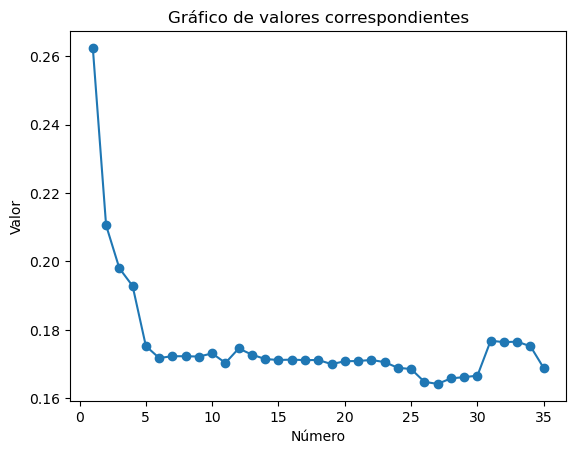

[np.float64(0.05187083163767131),
 np.float64(0.012565876647297441),
 np.float64(0.005193707798814645),
 np.float64(0.017560656041551048),
 np.float64(0.0034922471716359316),
 np.float64(-0.0005102811533684581),
 np.float64(3.162958530256166e-06),
 np.float64(8.775518632145318e-05),
 np.float64(-0.0009152401692258116),
 np.float64(0.002781958565643894),
 np.float64(-0.00423043224886685),
 np.float64(0.0018161399442542248),
 np.float64(0.0012781798872298356),
 np.float64(0.00028090693282847856),
 np.float64(-0.00011093591963279303),
 np.float64(0.00014883772868259926),
 np.float64(-3.691857683069122e-05),
 np.float64(0.0012037351044093814),
 np.float64(-0.0008415698101187641),
 np.float64(-7.04389508149883e-05),
 np.float64(-0.000302072479147375),
 np.float64(0.0006273199424797482),
 np.float64(0.0016600575459044253),
 np.float64(0.0003623680673673635),
 np.float64(0.0037399568835809194),
 np.float64(0.000616631162778436),
 np.float64(-0.001624922033745979),
 np.float64(-0.0003582177902

In [ ]:

for i in metrics:
    i:dict
    print(f"for n={list(i.keys())[0]}, Logerror= {list(i.values())[0][-1]}")
ns= list(range(1, 36))
rmsles = [list(i.values())[0][-1] for i in metrics]
plt.plot(ns, rmsles, marker='o')
plt.xlabel('Número')
plt.ylabel('Valor')
plt.title('Gráfico de valores correspondientes')
plt.show()
moves=[]
for i in ns:
    i2=i-1
    if i==ns[-1]:
        break
    moves.append(rmsles[i2]-rmsles[i])


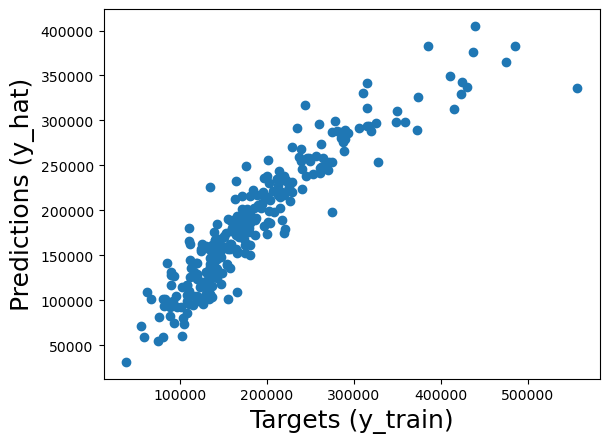

In [734]:
plt.scatter(y_test,y_hat)
plt.xlabel('Targets (y_train)',size=18)
plt.ylabel('Predictions (y_hat)',size=18)
plt.show()

In [735]:
import joblib
joblib.dump(reg, 'Model_1_1.joblib')

['Model_1_1.joblib']

In [736]:
df_test = pd.read_csv('../data/test.csv', index_col='Id')

In [737]:
df_test

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
Id,,,,,,,,,,,,,,,,,,,,,
1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,Inside,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2915,160,RM,21.0,1936,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,6,2006,WD,Normal
2916,160,RM,21.0,1894,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,4,2006,WD,Abnorml
2917,20,RL,160.0,20000,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,9,2006,WD,Abnorml


In [738]:
x_test_test= df_test[forlinearfeatures.index[:n].tolist()].copy()
x_test_test=x_test_test.fillna(x_test_test.median())
for column in columns_to_clean:
    if column in x_test_test.columns:
        x_test_test[f'has {column}']=(x_test_test[column]>0).astype(int)



In [739]:
pred_test=reg.predict(x_test_test)

In [740]:
submission = pd.DataFrame({
    'Id': x_test_test.index,
    'SalePrice': pred_test
})

# Guardar el archivo
submission.to_csv('submission_1_2.csv', index=False)
print("Archivo de submission creado exitosamente!")

Archivo de submission creado exitosamente!
